# 05. Pipeline común de entrenamiento para APTOS 2019

Este notebook define y valida el pipeline de datos que será utilizado
por las arquitecturas candidatas ResNet50 y EfficientNetB3+SE para la
clasificación de Retinopatía Diabética.

Las condiciones experimentales se mantienen comunes entre ambos modelos:

- mismas particiones Train, Validation y Test;
- mismas imágenes preprocesadas de 384 × 384 píxeles;
- mismo Data Augmentation aplicado únicamente sobre Train;
- mismo tratamiento del desbalance de clases;
- mismo tamaño de batch;
- mismas métricas de evaluación;
- mismo criterio de selección de arquitectura.

Las diferencias entre los experimentos estarán restringidas a la
arquitectura y a su preprocesamiento numérico específico de ImageNet.

## 2. Configuración y carga del manifiesto

Importación de librerías, definición de hiperparámetros comunes de entrada (resolución de 384 × 384, tamaño de lote 8 y semilla aleatoria 42) y carga del manifiesto de imágenes preprocesadas.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

PROJECT_ROOT = Path(
    "/mnt/c/Users/SeuNg720/Documents/TP1-RetiScan"
)
APTOS_ROOT = (
    PROJECT_ROOT
    / "datasets"
    / "RD"
    / "aptos2019"
)
METADATA_DIR = (
    APTOS_ROOT
    / "metadata"
)
PROCESSED_MANIFEST_PATH = (
    METADATA_DIR
    / "aptos2019_processed_manifest.csv"
)

IMAGE_SIZE = 384
BATCH_SIZE = 8
RANDOM_SEED = 42
AUTOTUNE_PARALLEL = 2
PREFETCH_SIZE = 1

manifest_df = pd.read_csv(
    PROCESSED_MANIFEST_PATH
)

print(
    "Registros:",
    len(manifest_df)
)
print(
    "\nDistribución por split:"
)
print(
    manifest_df[
        "experimental_split"
    ].value_counts()
)

I0000 00:00:1790750957.016518  246098 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790750957.072099  246098 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790750958.169617  246098 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Registros: 3487

Distribución por split:
experimental_split
train         2440
test           524
validation     523
Name: count, dtype: int64


## 3. Reconstrucción de rutas físicas y verificación de existencia

Reconstrucción de las rutas absolutas a partir de las rutas relativas registradas en el manifiesto y comprobación formal de la presencia física de los 3487 archivos en el sistema de almacenamiento.

In [2]:
manifest_df[
    "absolute_processed_path"
] = (
    manifest_df[
        "processed_path"
    ]
    .apply(
        lambda x:
            str(
                APTOS_ROOT
                / x
            )
    )
)
manifest_df[
    "file_exists"
] = (
    manifest_df[
        "absolute_processed_path"
    ]
    .apply(
        lambda x:
            Path(x).exists()
    )
)

print(
    "Archivos encontrados:",
    int(
        manifest_df[
            "file_exists"
        ].sum()
    )
)
print(
    "Archivos faltantes:",
    int(
        (
            ~manifest_df[
                "file_exists"
            ]
        ).sum()
    )
)

Archivos encontrados: 3487
Archivos faltantes: 0


### 3.1. Separación de los conjuntos experimentales Train, Validation y Test

Extracción de los subconjuntos en dataframes individuales manteniendo sus índices reseteados y verificando sus dimensiones respectivas (2440, 523 y 524).

In [3]:
train_df = (
    manifest_df[
        manifest_df[
            "experimental_split"
        ] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)
validation_df = (
    manifest_df[
        manifest_df[
            "experimental_split"
        ] == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)
test_df = (
    manifest_df[
        manifest_df[
            "experimental_split"
        ] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Train:",
    len(train_df)
)
print(
    "Validation:",
    len(validation_df)
)
print(
    "Test:",
    len(test_df)
)

Train: 2440
Validation: 523
Test: 524


## 4. Cálculo de pesos de clase

APTOS 2019 presenta un desbalance considerable entre los cinco grados
diagnósticos.

Para reducir el predominio de las clases más frecuentes durante el
entrenamiento se utilizan pesos de clase calculados exclusivamente a
partir del conjunto Train.

No se realiza oversampling ni se modifican Validation o Test.

In [4]:
classes = np.array(
    sorted(
        train_df[
            "diagnosis"
        ].unique()
    )
)
class_weights_array = (
    compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=train_df[
            "diagnosis"
        ].to_numpy()
    )
)
class_weights = {
    int(class_id):
        float(weight)
    for class_id, weight
    in zip(
        classes,
        class_weights_array
    )
}

print(
    "Pesos de clase:"
)
for class_id, weight in (
    class_weights.items()
):
    print(
        f"Clase {class_id}: {weight:.6f}"
    )

Pesos de clase:
Clase 0: 0.388226
Clase 1: 2.067797
Clase 2: 0.756589
Clase 3: 4.135593
Clase 4: 2.652174


## 5. Data Augmentation

El aumento de datos se aplica exclusivamente sobre Train y de manera
dinámica durante el entrenamiento.

Se utilizan transformaciones moderadas que preservan la estructura
anatómica general de la retina:

- inversión horizontal;
- rotaciones pequeñas;
- zoom moderado;
- variación moderada de contraste.

Validation y Test no reciben Data Augmentation.

In [5]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            "horizontal",
            seed=RANDOM_SEED
        ),
        tf.keras.layers.RandomRotation(
            factor=0.03,
            fill_mode="constant",
            fill_value=0.0,
            seed=RANDOM_SEED
        ),
        tf.keras.layers.RandomZoom(
            height_factor=(
                -0.10,
                0.10
            ),
            width_factor=(
                -0.10,
                0.10
            ),
            fill_mode="constant",
            fill_value=0.0,
            seed=RANDOM_SEED
        ),
        tf.keras.layers.RandomContrast(
            factor=0.10,
            seed=RANDOM_SEED
        )
    ],
    name="rd_data_augmentation"
)

W0000 00:00:1790750970.883700  246098 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1790750970.886955  246098 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1790750971.081790  246098 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9217 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070, pci bus id: 0000:01:00.0, compute capability: 12.0a


## 6. Carga y decodificación común de imágenes

Se define la función de carga a nivel de grafo de TensorFlow. La función lee el archivo PNG desde el disco, lo decodifica a 3 canales RGB en rango [0, 255] en formato `float32`, y asigna la etiqueta entera correspondiente.

In [6]:
def load_image_and_label(
    image_path,
    label
):
    image = tf.io.read_file(
        image_path
    )
    image = tf.image.decode_png(
        image,
        channels=3
    )
    image = tf.cast(
        image,
        tf.float32
    )
    image.set_shape(
        [
            IMAGE_SIZE,
            IMAGE_SIZE,
            3
        ]
    )
    label = tf.cast(
        label,
        tf.int32
    )
    return (
        image,
        label
    )

## 7. Construcción de tf.data.Dataset

Implementación del pipeline de alimentación de datos optimizado para entrenamiento mediante `tf.data`. Se incorpora barajado (`shuffle`) exclusivamente para Train, procesamiento paralelo (`num_parallel_calls`), empaquetado en lotes (`batch`) y precarga en memoria (`prefetch`).

In [7]:
def build_dataset(
    dataframe,
    training=False
):
    paths = (
        dataframe[
            "absolute_processed_path"
        ]
        .to_numpy()
    )
    labels = (
        dataframe[
            "diagnosis"
        ]
        .to_numpy(
            dtype=np.int32
        )
    )
    dataset = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                paths,
                labels
            )
        )
    )
    if training:
        dataset = dataset.shuffle(
            buffer_size=len(
                dataframe
            ),
            seed=RANDOM_SEED,
            reshuffle_each_iteration=True
        )
    dataset = dataset.map(
        load_image_and_label,
        num_parallel_calls=
            AUTOTUNE_PARALLEL
    )
    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False
    )
    dataset = dataset.prefetch(
        PREFETCH_SIZE
    )
    return dataset

### 7.1. Instanciación de los conjuntos de datos experimentales

Creación de los objetos `tf.data.Dataset` para `train_ds`, `validation_ds` y `test_ds` utilizando el tamaño de lote común configurado (`BATCH_SIZE = 8`).

In [8]:
train_ds = build_dataset(
    train_df,
    training=True
)
validation_ds = build_dataset(
    validation_df,
    training=False
)
test_ds = build_dataset(
    test_df,
    training=False
)

## 8. Verificación de dimensiones, tipos y rango de valores

Extracción de un lote de prueba para comprobar que las dimensiones espaciales coincidan estrictamente con (8, 384, 384, 3), el tipo sea `float32`, el rango de intensidades sea [0.0, 255.0] y las etiquetas pertenezcan al dominio de las 5 categorías diagnósticas.

In [9]:
train_images, train_labels = next(
    iter(train_ds)
)
print(
    "Train images:",
    train_images.shape
)
print(
    "Train labels:",
    train_labels.shape
)
print(
    "dtype images:",
    train_images.dtype
)
print(
    "Min:",
    float(
        tf.reduce_min(
            train_images
        )
    )
)
print(
    "Max:",
    float(
        tf.reduce_max(
            train_images
        )
    )
)
print(
    "Labels:",
    train_labels.numpy()
)

Train images: (8, 384, 384, 3)
Train labels: (8,)
dtype images: <dtype: 'float32'>
Min: 0.0
Max: 255.0
Labels: [0 0 2 4 0 0 0 0]


## 9. Integración del Data Augmentation en los modelos

El Data Augmentation no se incorpora directamente en los objetos
`tf.data.Dataset`.

En su lugar, la misma secuencia de transformaciones será incluida como
parte inicial de ambas arquitecturas candidatas y estará activa únicamente
cuando el modelo se encuentre en modo de entrenamiento.

De esta manera:

- Train recibe aumento de datos dinámico.
- Validation no recibe aumento de datos.
- Test no recibe aumento de datos.
- ResNet50 y EfficientNetB3+SE utilizan exactamente la misma política
  de transformación.

Los datasets base permanecen en formato RGB `float32` dentro del rango
[0, 255].

### 9.1. Comprobación y evaluación numérica del Data Augmentation

Aplicación de la capa de aumento de datos sobre el lote de entrenamiento para comprobar dimensiones y rangos de salida.

In [10]:
augmented_images = data_augmentation(
    train_images,
    training=True
)
print(
    "Shape original:",
    train_images.shape
)
print(
    "Shape augmented:",
    augmented_images.shape
)
print(
    "Min augmented:",
    float(
        tf.reduce_min(
            augmented_images
        )
    )
)
print(
    "Max augmented:",
    float(
        tf.reduce_max(
            augmented_images
        )
    )
)

Shape original: (8, 384, 384, 3)
Shape augmented: (8, 384, 384, 3)
Min augmented: 0.0
Max augmented: 255.0


### 9.1.1. Inspección visual comparativa: Original vs. Augmentation

Visualización de cuatro pares de retinografías para comprobar que las variaciones de rotación, traslación, zoom y contraste sean moderadas y anatómicamente verosímiles.

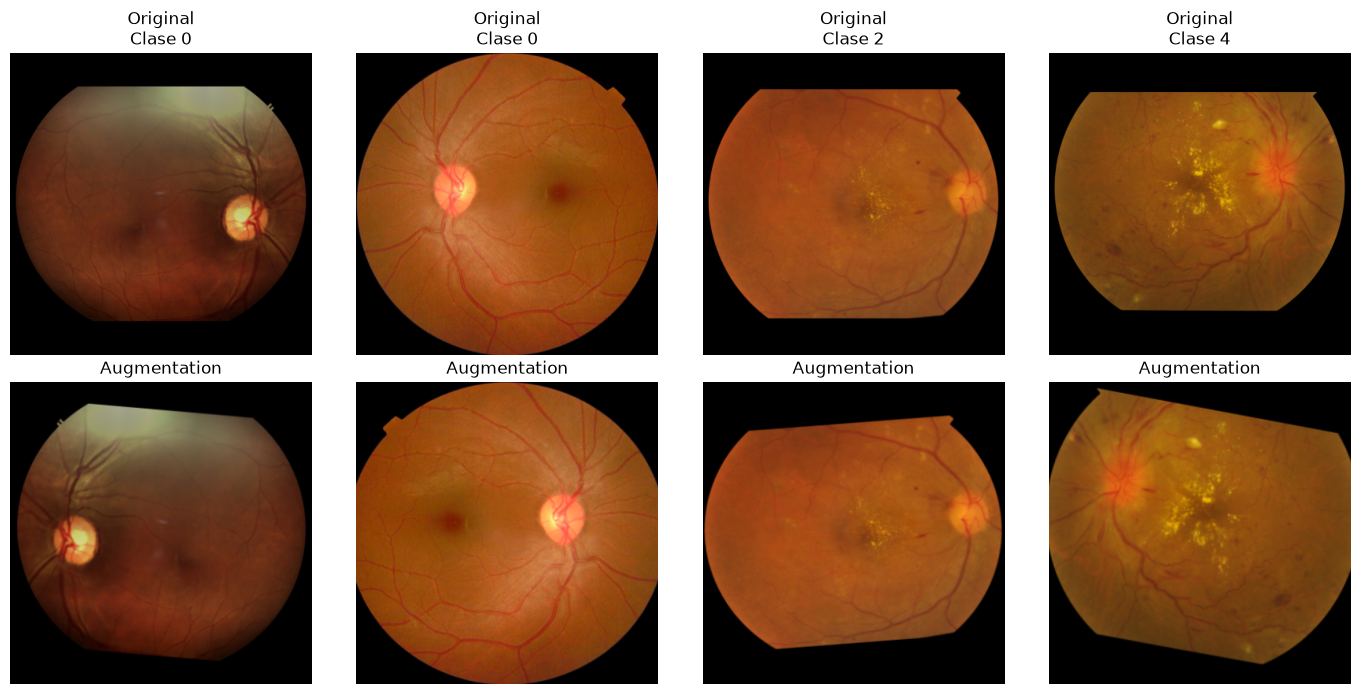

In [11]:
import matplotlib.pyplot as plt

n_images = 4
fig, axes = plt.subplots(
    2,
    n_images,
    figsize=(14, 7)
)

for i in range(n_images):
    axes[0, i].imshow(
        train_images[i]
        .numpy()
        .astype(np.uint8)
    )
    axes[0, i].set_title(
        f"Original\nClase "
        f"{train_labels[i].numpy()}"
    )
    axes[0, i].axis("off")

    augmented = (
        tf.clip_by_value(
            augmented_images[i],
            0,
            255
        )
        .numpy()
        .astype(np.uint8)
    )
    axes[1, i].imshow(
        augmented
    )
    axes[1, i].set_title(
        "Augmentation"
    )
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## 10. Criterio predefinido para la comparación de arquitecturas

La selección entre ResNet50 y EfficientNetB3+SE se realizará utilizando
exclusivamente el conjunto Validation.

Debido a que la clasificación de Retinopatía Diabética presenta una
estructura ordinal de cinco niveles, la métrica principal de comparación
será **Quadratic Weighted Kappa (QWK)**.

El criterio experimental queda definido como:

1. **Métrica principal:** Quadratic Weighted Kappa (QWK).
2. **Métrica secundaria:** Macro F1-Score.
3. **Métricas descriptivas complementarias:**
   - Accuracy;
   - Macro Recall;
   - Precision Macro;
   - matriz de confusión;
   - comportamiento por clase.
4. **Complemento computacional:**
   - número de parámetros;
   - tiempo de entrenamiento;
   - requerimientos de memoria.

El conjunto Test no participará en la selección de arquitectura y
permanecerá reservado para la evaluación final del modelo seleccionado.

## 11. Función común para cálculo de métricas de evaluación

Implementación de la rutina estandarizada para evaluar el rendimiento de clasificación en problemas ordinales de 5 clases mediante QWK, Macro F1, Accuracy, Precision Macro y Recall Macro.

In [12]:
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix
)

def calculate_rd_metrics(
    y_true,
    y_pred
):
    return {
        "qwk":
            cohen_kappa_score(
                y_true,
                y_pred,
                weights="quadratic"
            ),
        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),
        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),
        "macro_precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),
        "macro_recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            )
    }

## 12. Registro y persistencia de la configuración del pipeline

Almacenamiento de todos los hiperparámetros del pipeline común en formato JSON dentro de `results/RD/training_pipeline/` para asegurar reproducibilidad metodológica.

In [13]:
import json

PIPELINE_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "RD"
    / "training_pipeline"
)
PIPELINE_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)
PIPELINE_CONFIG_PATH = (
    PIPELINE_RESULTS_DIR
    / "aptos2019_training_pipeline_config.json"
)

pipeline_config = {
    "dataset": "APTOS 2019",
    "num_classes": 5,
    "image_size": [
        IMAGE_SIZE,
        IMAGE_SIZE
    ],
    "batch_size":
        BATCH_SIZE,
    "random_seed":
        RANDOM_SEED,
    "train_images":
        len(train_df),
    "validation_images":
        len(validation_df),
    "test_images":
        len(test_df),
    "class_weights":
        class_weights,
    "primary_metric":
        "Quadratic Weighted Kappa (QWK)",
    "secondary_metric":
        "Macro F1-Score"
}

with open(
    PIPELINE_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        pipeline_config,
        f,
        indent=4,
        ensure_ascii=False
    )

print(
    "Configuración guardada en:",
    PIPELINE_CONFIG_PATH
)

Configuración guardada en: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/results/RD/training_pipeline/aptos2019_training_pipeline_config.json


## 13. Conclusión

Se definió y validó el pipeline común que será utilizado para comparar
ResNet50 y EfficientNetB3+SE sobre APTOS 2019.

El pipeline utiliza las mismas 2440 imágenes de Train, 523 imágenes de
Validation y 524 imágenes de Test previamente congeladas.

Las imágenes de entrada tienen dimensiones 384 × 384, tres canales RGB,
tipo `float32` y rango [0, 255].

El desbalance de clases se aborda mediante pesos calculados exclusivamente
sobre Train, sin oversampling físico.

El Data Augmentation será aplicado dinámicamente y únicamente durante el
entrenamiento mediante inversión horizontal, rotación, zoom y variación
moderada de contraste.

La comparación entre arquitecturas utilizará como métrica principal
Quadratic Weighted Kappa (QWK) y como métrica secundaria Macro F1,
calculadas exclusivamente sobre Validation.

El conjunto Test permanecerá aislado hasta la evaluación final del modelo
seleccionado.